In [54]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt

# 1. Parse partition values (YYYYMMDD) into datetime
def parse_partitions(partition_list):
    return pd.to_datetime(partition_list, format="%Y%m%d").sort_values()


# 2. Compute time deltas (differences in days between updates)
def compute_deltas(dates):
    # Calculate the time differences (deltas)
    deltas = dates.diff().dropna()  # Compute differences
    
    # Convert timedeltas to days using .total_seconds() and dividing by the number of seconds in a day (86400)
    deltas_in_days = deltas.total_seconds() / 86400
    return pd.Series(deltas_in_days)  # Ensure it is a Series, not an Index

# 3. Analyze regularity (frequency, std, and entropy)
def analyze_intervals(deltas):
    freq = deltas.value_counts().sort_index()
    std = deltas.std()  # Calculate standard deviation
    probs = freq / freq.sum()
    ent = entropy(probs)
    return {
        "frequency": freq,
        "std_dev": std,
        "entropy": ent
    }

# 4. Create binary time series
def create_binary_series(dates):
    full_range = pd.date_range(start=dates.min(), end=dates.max())
    series = pd.Series(0, index=full_range)
    series.loc[dates] = 1
    return series

# 5. Compute autocorrelation
def compute_autocorrelation(binary_series, max_lag=30):
    return pd.Series([binary_series.autocorr(lag=i) for i in range(1, max_lag + 1)], 
                     index=range(1, max_lag + 1))


# 6. Compute FFT spectrum
def compute_fft(binary_series):
    values = binary_series.values
    fft_vals = np.fft.fft(values)
    fft_freqs = np.fft.fftfreq(len(values), d=1)  # Daily spacing
    spectrum = np.abs(fft_vals)
    return pd.Series(spectrum[1:len(values)//2], index=fft_freqs[1:len(values)//2])  # Skip 0 freq

# 7. Full pipeline for assessing regularity
def assess_update_regularity(partition_list, max_lag=35):
    dates = parse_partitions(partition_list)
    deltas = compute_deltas(dates)
    stats = analyze_intervals(deltas)
    binary_series = create_binary_series(dates)
    autocorr = compute_autocorrelation(binary_series, max_lag=max_lag)
    fft_spectrum = compute_fft(binary_series)
    
    return {
        "parsed_dates": dates,
        "deltas": deltas,
        "stats": stats,
        "binary_series": binary_series,
        "autocorrelation": autocorr,
        "fft_spectrum": fft_spectrum
    }


# Example Usage
example_partitions = [
    20240101, 20240102, 20240103, 20240110,
    20240111, 20240112, 20240119, 20240120,
    20240121, 20240128, 20240129
]

weekly = [20240101, 20240108, 20240109]

interesting_dates = [
    20240101,  # Monday
    20240108,  # Monday
    20240115,  # Monday
    20240122,  # Monday
    20240123,  # Tuesday - burst
    20240124,  # Wednesday - burst
    20240205,  # Skipped 1 week (Jan 29 missing)
    20240212,  # Monday
    20240226,  # Skipped 1 week (Feb 19 missing)
    20240227,  # Tuesday - burst
    20240228,  # Wednesday - burst
    20240304,  # Monday
    20240311,  # Monday
    20240318,  # Monday
]

perfect_regular_dates = [
    20240101,  # Monday
    20240108,
    20240115,
    20240122,
    20240129,
    20240205,
    20240212,
    20240219,
    20240226,
    20240304,
    20240311,
    20240318,
    20240325,
    20240401
]

perfect_regular_monthly_dates = [
    20230101,  # January 1st, 2023
    20230201,  # February 1st, 2023
    20230301,  # March 1st, 2023
    20230401,  # April 1st, 2023
    20230501,  # May 1st, 2023
    20230601,  # June 1st, 2023
    20230701,  # July 1st, 2023
    20230801,  # August 1st, 2023
    20230901,  # September 1st, 2023
    20231001,  # October 1st, 2023
    20231101,  # November 1st, 2023
    20231201   # December 1st, 2023
]


results = assess_update_regularity(perfect_regular_dates)

# Print results
print("Update Interval Frequencies:\n", results["stats"]["frequency"])
print("Standard Deviation:", results["stats"]["std_dev"])
print("Entropy:", results["stats"]["entropy"])
print("Binary series:")
print(results["binary_series"])



Update Interval Frequencies:
 7.0    13
Name: count, dtype: int64
Standard Deviation: 0.0
Entropy: 0.0
Binary series:
2024-01-01    1
2024-01-02    0
2024-01-03    0
2024-01-04    0
2024-01-05    0
             ..
2024-03-28    0
2024-03-29    0
2024-03-30    0
2024-03-31    0
2024-04-01    1
Freq: D, Length: 92, dtype: int64


<Axes: title={'center': 'Autocorrelation of Updates'}, xlabel='Lag (days)'>

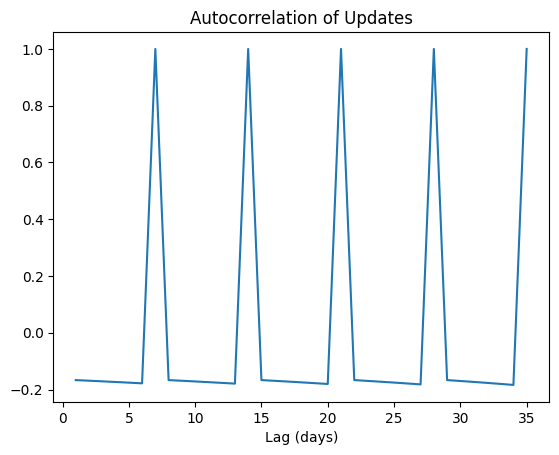

In [55]:
# Plot Autocorrelation and FFT Spectrum
results["autocorrelation"].plot(title="Autocorrelation of Updates", xlabel="Lag (days)")

<Axes: title={'center': 'FFT Spectrum of Update Pattern'}, xlabel='Frequency (1/days)'>

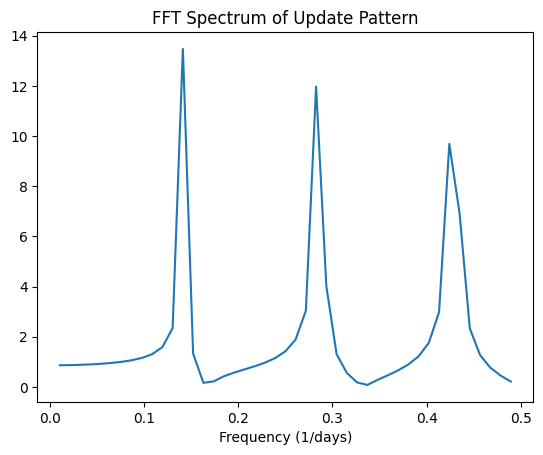

In [56]:
results["fft_spectrum"].plot(title="FFT Spectrum of Update Pattern", xlabel="Frequency (1/days)")

<Axes: >

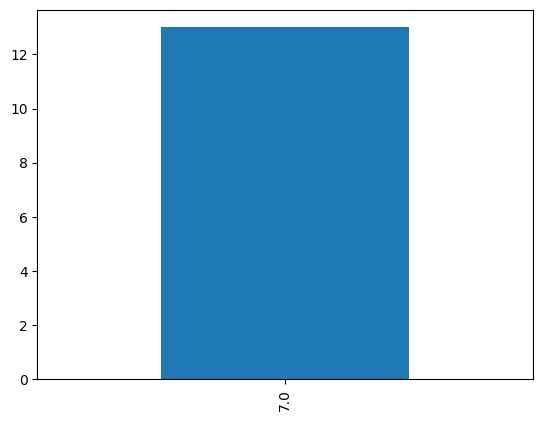

In [57]:
results["stats"]["frequency"].plot(kind="bar")

<Axes: >

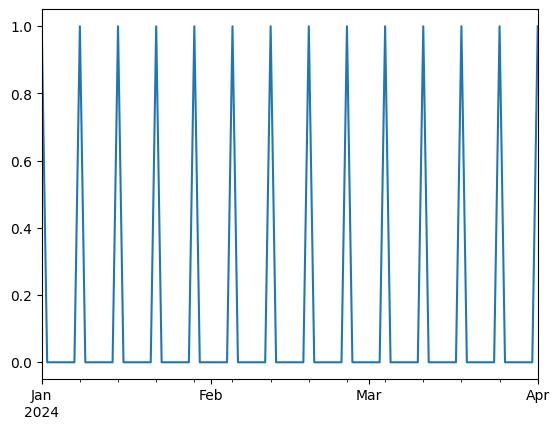

In [58]:
results["binary_series"].plot()